In [94]:
from PIL import Image
from matplotlib import pyplot as plt
import numpy as np
from pathlib import Path
from skimage.metrics import structural_similarity as ssim

In [95]:
path = "test_image/Lenna_(test_image).png"

img = Image.open(path).convert("RGB")


In [96]:
class JPEGCodec:
    def __init__(self, block_size: int = 8, q_y: int = 10, q_c: int = 16):
        self.N = block_size
        self.C = self._dct_matrix(block_size)
        self.q_y = q_y
        self.q_c = q_c

    def _dct_matrix(self, N: int) -> np.ndarray:
        C = np.zeros((N, N), dtype=np.float64)
        for i in range(N):
            for j in range(N):
                alpha = np.sqrt(1 / N) if i == 0 else np.sqrt(2 / N)
                C[i, j] = alpha * np.cos(((2 * j + 1) * i * np.pi) / (2 * N))
        return C
    
    def _split_blocks(self, channel):
        H, W = channel.shape
        assert H % self.N == 0 and W % self.N == 0, "Image dimensions must be divisible by block size"
        return channel.reshape(
            H // self.N, self.N,
            W // self.N, self.N
        ).transpose(0, 2, 1, 3)

    def _merge_blocks(self, blocks):
        nb_h, nb_w, bh, bw = blocks.shape
        return blocks.transpose(0, 2, 1, 3).reshape(nb_h * bh, nb_w * bw)
    
    def _dct2(self, block):
        return self.C @ block @ self.C.T
    
    def _idct2(self, block):
        return self.C.T @ block @ self.C
    
    def transform_blocks(self, blocks):
        out = np.empty_like(blocks, dtype=np.float64)
        for i in range(blocks.shape[0]):
            for j in range(blocks.shape[1]):
                out[i, j] = self._dct2(blocks[i, j])
        return out
    
    def inverse_transform_blocks(self, blocks):
        out = np.empty_like(blocks, dtype=np.float64)
        for i in range(blocks.shape[0]):
            for j in range(blocks.shape[1]):
                out[i, j] = self._idct2(blocks[i, j])
        return out
    
    
    def transform(self, image: Image.Image) -> dict:
        image = image.convert("YCbCr")
        arr = np.asarray(image, dtype=np.uint8).astype(np.float64) - 128.0
        channels = []

        for c in range(3):
            blocks = self._split_blocks(arr[:, :, c])
            dct_blocks = self.transform_blocks(blocks)
            channels.append(dct_blocks)

        return {
            "ch1": channels[0],
            "ch2": channels[1],
            "ch3": channels[2]
        }

    def inverse_transform(self, encoded: dict) -> Image.Image:
        rec_channels = []

        for key in ["ch1", "ch2", "ch3"]:
            blocks = self.inverse_transform_blocks(encoded[key])
            rec_channels.append(self._merge_blocks(blocks))
        
        rec = np.stack(rec_channels, axis=-1)
        return Image.fromarray(np.clip(rec + 128.0, 0, 255).astype(np.uint8), mode="YCbCr").convert("RGB")
    

    # Quantization
    def quantize(self, transformed: dict) -> dict:
        quantized = {}
        for key in ["ch1", "ch2", "ch3"]:
            q = self.q_y if key == "ch1" else self.q_c
            quantized[key] = np.round(transformed[key] / q).astype(np.int32)
        return quantized
    
    def dequantize(self, quantized: dict) -> dict:
        dequantized = {}
        for key in ["ch1", "ch2", "ch3"]:
            q = self.q_y if key == "ch1" else self.q_c
            dequantized[key] = (quantized[key] * q).astype(np.float64)
        return dequantized

    def encode(self, image: Image.Image) -> dict:
        transformed = self.transform(image)
        quantized = self.quantize(transformed)
        return quantized
    
    def decode(self, encoded: dict) -> Image.Image:
        dequantized = self.dequantize(encoded)
        output = self.inverse_transform(dequantized)
        return output

In [97]:
def MSE(original: Image.Image, reconstructed: Image.Image) -> float:
    arr_orig = np.asarray(original, dtype=np.float64)
    arr_rec = np.asarray(reconstructed, dtype=np.float64)
    mse = np.mean((arr_orig - arr_rec) ** 2)
    return mse

def PSNR(original: Image.Image, reconstructed: Image.Image) -> float:
    mse = MSE(original, reconstructed)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0
    psnr = 10 * np.log10(max_pixel**2 / mse)
    return psnr

def SSIM(original: Image.Image, reconstructed: Image.Image) -> float:
    arr_orig = np.asarray(original, dtype=np.float64)
    arr_rec = np.asarray(reconstructed, dtype=np.float64)
    ssim_value = ssim(arr_orig, arr_rec, multichannel=True, channel_axis=2,data_range=255)
    return ssim_value

def entropy(image: Image.Image) -> float:
    symbols = np.asarray(image, dtype=np.uint8)
    symbols = symbols.ravel()
    values, counts = np.unique(symbols, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs))

def estimate_bpp(encoded: Image.Image, image: Image.Image) -> float:
    H_total_bits = 0
    total_symbols = 0

    for key in ["ch1", "ch2", "ch3"]:
        coeffs = encoded[key]
        H = entropy(coeffs)
        n = coeffs.size

        H_total_bits += H * n
        total_symbols += n
    
    W, H = image.size
    return H_total_bits / (W * H)


In [98]:
q_y_values = [1,2,3,4,5,10,20,30,40,50,100, 200]

mse_values = []
psnr_values = []
ssim_values = []
decoded_images = []
estimated_bpps = []

for q_y in q_y_values:
    codec = JPEGCodec(block_size=8, q_y=q_y, q_c=q_y*1.6)
    encoded = codec.encode(img)
    decoded = codec.decode(encoded)

    decoded_images.append(decoded)
    mse_values.append(MSE(img, decoded))
    psnr_values.append(PSNR(img, decoded))
    ssim_values.append(SSIM(img, decoded))
    estimated_bpps.append(estimate_bpp(encoded, img))


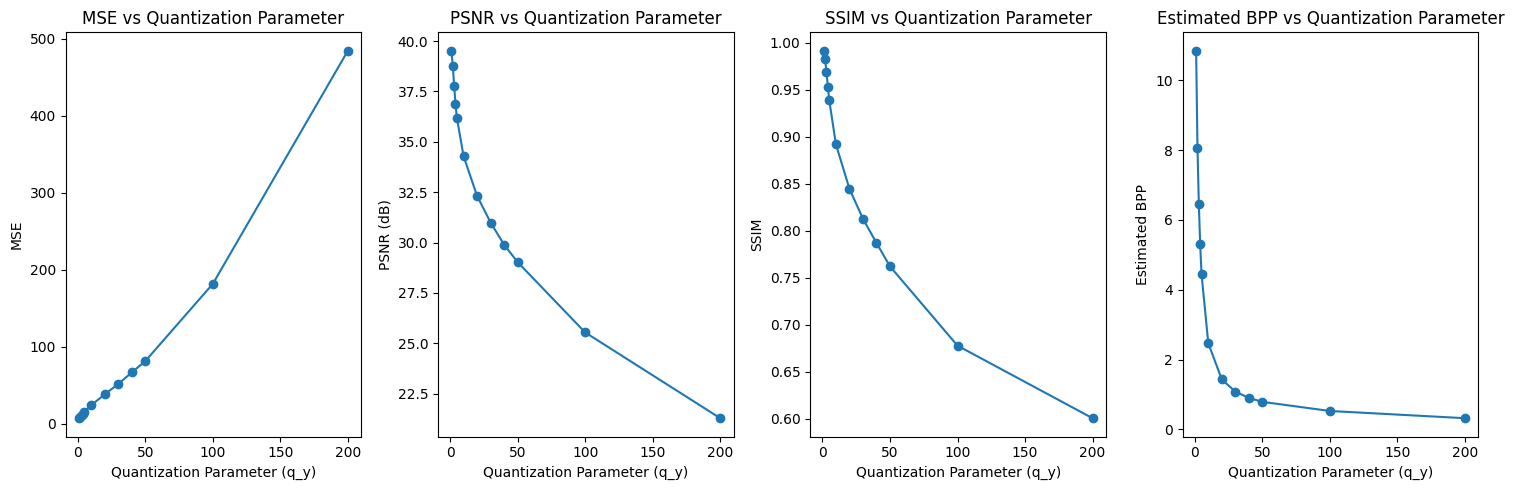

In [103]:
# Plotting the results
plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1)
plt.plot(q_y_values, mse_values, marker='o')
# plt.xscale('log')
plt.xlabel('Quantization Parameter (q_y)')
plt.ylabel('MSE')
plt.title('MSE vs Quantization Parameter')
plt.subplot(1, 4, 2)
plt.plot(q_y_values, psnr_values, marker='o')
# plt.xscale('log')
plt.xlabel('Quantization Parameter (q_y)')
plt.ylabel('PSNR (dB)')
plt.title('PSNR vs Quantization Parameter')
plt.subplot(1, 4, 3)
plt.plot(q_y_values, ssim_values, marker='o')
# plt.xscale('log')
plt.xlabel('Quantization Parameter (q_y)')
plt.ylabel('SSIM')
plt.title('SSIM vs Quantization Parameter')
plt.subplot(1, 4, 4)
plt.plot(q_y_values, estimated_bpps, marker='o')
# plt.xscale('log')
plt.xlabel('Quantization Parameter (q_y)')
plt.ylabel('Estimated BPP')
plt.title('Estimated BPP vs Quantization Parameter')
plt.tight_layout()
plt.show()

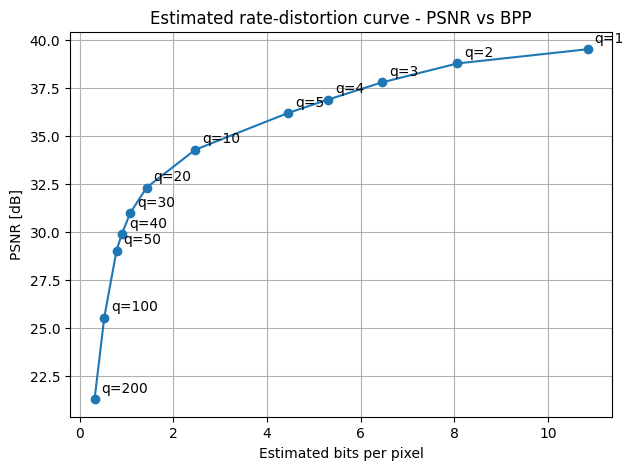

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(estimated_bpps, psnr_values, marker="o")

for bpp, psnr, q in zip(estimated_bpps, psnr_values, q_y_values):
    plt.annotate(f"q={q}", (bpp, psnr), textcoords="offset points", xytext=(5, 5))

plt.xlabel("Estimated bits per pixel")
plt.ylabel("PSNR [dB]")
plt.title("Estimated rate-distortion curve - PSNR vs BPP") 
plt.grid(True)
plt.show()

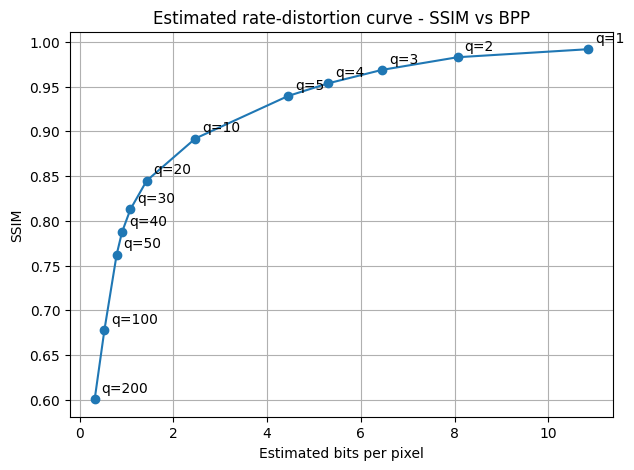

In [105]:
plt.figure(figsize=(7, 5))
plt.plot(estimated_bpps, ssim_values, marker="o")

for bpp, ssim, q in zip(estimated_bpps, ssim_values, q_y_values):
    plt.annotate(f"q={q}", (bpp, ssim), textcoords="offset points", xytext=(5, 5))

plt.xlabel("Estimated bits per pixel")
plt.ylabel("SSIM")
plt.title("Estimated rate-distortion curve - SSIM vs BPP")
plt.grid(True)
plt.show()

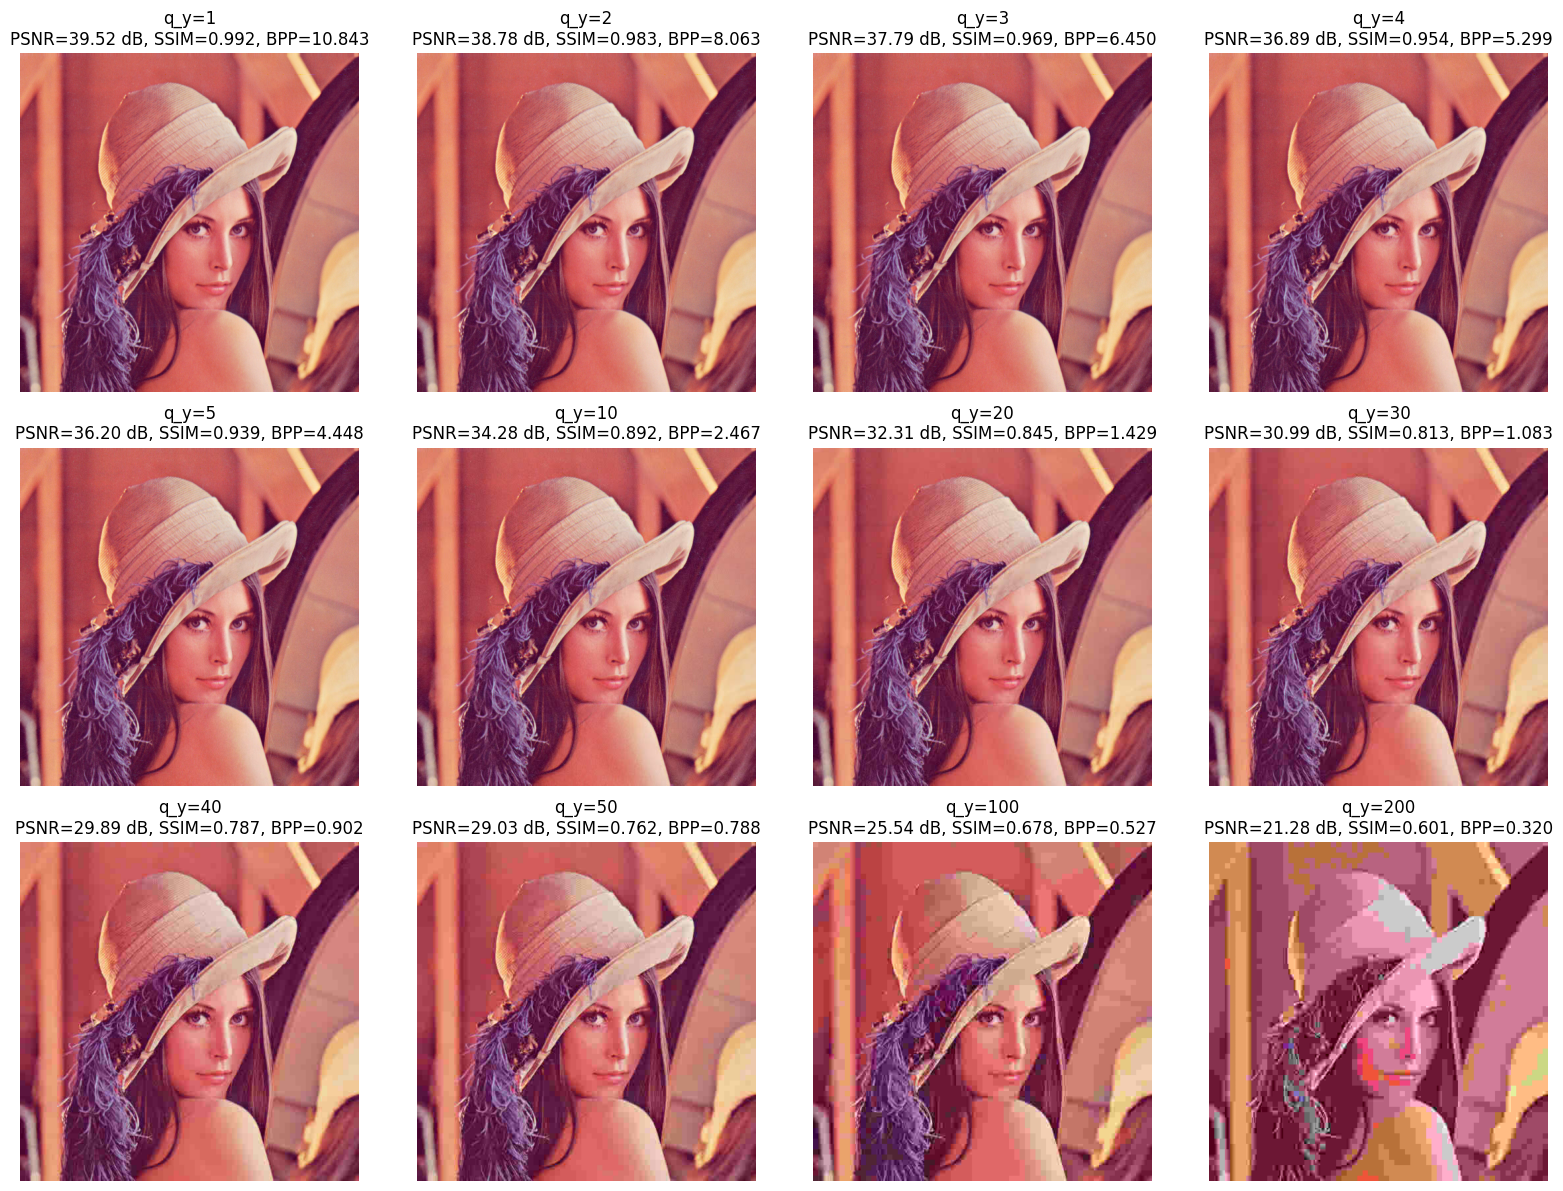

In [102]:
n = len(q_y_values)
cols = 4
rows = int(np.ceil(n / cols))

plt.figure(figsize=(4 * cols, 4 * rows))

for i, (q_y, decoded, psnr, ssim) in enumerate(
    zip(q_y_values, decoded_images, psnr_values, ssim_values)
):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(decoded)
    plt.title(f"q_y={q_y}\nPSNR={psnr:.2f} dB, SSIM={ssim:.3f}, BPP={estimated_bpps[i]:.3f}")
    plt.axis("off")

plt.tight_layout()
plt.show()